# Análise de Preço Médio dos Livros (1970-2023)

Vamos calcular e plotar o preço médio por ano.

## Parte 1: Importar bibliotecas e carregar dados

- **pandas**: manipulação de dados (ler CSV, agrupar, calcular médias)
- **matplotlib**: criar o gráfico

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

Carregando o CSV com o pandas. O `pd.read_csv()` já transforma automaticamente em um **DataFrame** (tabela).

In [18]:
df = pd.read_csv("BooksDatasetClean.csv")
df.head()

,Title,Authors,Description,Category,Publisher,Price Starting With ($),Publish Date (Month),Publish Date (Year)
0,Goat Brothers,"By Colton, Larry",NaN,"History , General",Doubleday,8.79,January,1993
1,The Missing Person,"By Grumbach, Doris",NaN,"Fiction , General",Putnam Pub Group,4.99,March,1981
2,Don't Eat Your Heart Out Cookbook,"By Piscatella, Joseph C.",NaN,"Cooking , Reference",Workman Pub Co,4.99,September,1983
3,When Your Corporate Umbrella Begins to Leak: A...,"By Davis, Paul D.",NaN,NaN,Natl Pr Books,4.99,April,1991
4,Amy Spangler's Breastfeeding : A Parent's Guide,"By Spangler, Amy",NaN,NaN,Amy Spangler,5.32,February,1997


## Parte 2: Filtrar, remover outlier e agrupar os dados

Vamos filtrar apenas os anos >= 1970, **remover o outlier** "Smoky the Cowhorse" (1926, \$879.50) 
que descobrimos distorcendo o gráfico, agrupar por ano e calcular a média de preço.

In [19]:
# Converter as colunas para numérico
df["Publish Date (Year)"] = pd.to_numeric(df["Publish Date (Year)"])
df["Price Starting With ($)"] = pd.to_numeric(df["Price Starting With ($)"], errors="coerce")

# Filtrar apenas anos >= 1970
df_filtrado = df[df["Publish Date (Year)"] >= 1970]

# Remover o outlier "Smoky the Cowhorse" de 1926 (preço de $879.50)
df_filtrado = df_filtrado[~((df_filtrado["Title"] == "Smoky the Cowhorse") & (df_filtrado["Publish Date (Year)"] == 1926))]

# Agrupar por ano e calcular preço médio
preco_medio = df_filtrado.groupby("Publish Date (Year)")["Price Starting With ($)"].mean()

# Mostrar as primeiras linhas
preco_medio.head()

Publish Date (Year)
1970     9.633935
1971    10.615913
1972     8.697694
1973     9.028390
1974     8.169444
Name: Price Starting With ($), dtype: float64

## Parte 3: Plotar o gráfico

Agora vamos gerar o gráfico de linha com matplotlib.

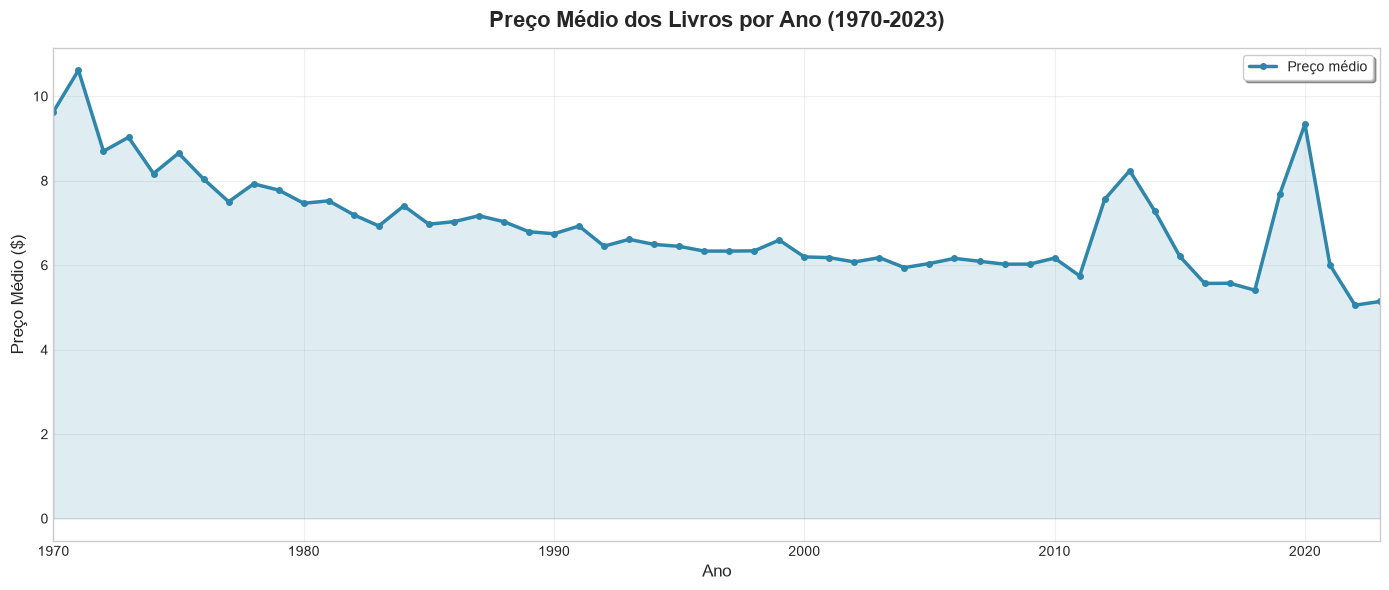

In [20]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(preco_medio.index, preco_medio.values,
        color="#2E86AB", linewidth=2.5, marker="o", markersize=4,
        label="Preço médio")
ax.fill_between(preco_medio.index, preco_medio.values,
                alpha=0.15, color="#2E86AB")

ax.set_title("Preço Médio dos Livros por Ano (1970-2023)",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Ano", fontsize=12)
ax.set_ylabel("Preço Médio ($)", fontsize=12)
ax.legend(frameon=True, fancybox=True, shadow=True)
ax.set_xlim(1970, 2023)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Pronto! 🎉

O gráfico mostra a evolução do preço médio ao longo dos anos.

**Resumo do que fizemos:**
1. `import pandas as pd` → importa a biblioteca pandas
2. `pd.read_csv()` → lê o CSV e cria um DataFrame
3. `pd.to_numeric()` → converte ano e preço para número
4. `df["ano"] >= 1970` → filtra linhas (condição)
5. `df_filtrado[~(condição)]` → remove outlier (Smoky the Cowhorse, 1926)
6. `groupby().mean()` → agrupa por ano e calcula a média
7. `plt.plot()` → cria o gráfico de linha